# N1 · VQ 重建: 图像变成离散 token (Visual Tokenization)

> 配套 10.4-L1 · 用 VQ 码本把合成图量化成离散 token 再重建, 画「码本大小 → 重建质量」曲线,
> 亲眼看图如何变成一串「视觉的词」。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np
import vq_tokenizer as vq
print('vq_tokenizer 就绪')

vq_tokenizer 就绪


## 1. 一张图 → 离散 token → 重建 (不同码本大小)

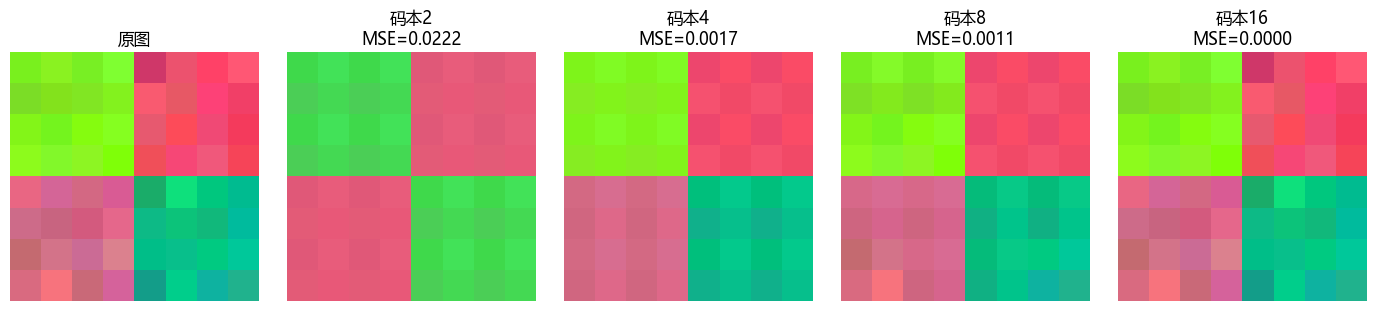

→ 码本越大, 重建越接近原图 (更多视觉原型)。


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
img = vq.make_image(size=8, seed=1)
sizes = [2, 4, 8, 16]
fig, axes = plt.subplots(1, len(sizes)+1, figsize=(14,3))
axes[0].imshow(np.clip(img,0,1)); axes[0].set_title('原图'); axes[0].axis('off')
for ax, k in zip(axes[1:], sizes):
    recon, tokens, mse = vq.reconstruct(img, codebook_size=k, patch=2, seed=1)
    ax.imshow(np.clip(recon,0,1)); ax.set_title(f'码本{k}\nMSE={mse:.4f}'); ax.axis('off')
plt.tight_layout(); plt.show()
print('→ 码本越大, 重建越接近原图 (更多视觉原型)。')

## 2. 看一串「视觉 token」(图被压成离散编号, 像文本的词 id)

In [3]:
recon, tokens, mse = vq.reconstruct(img, codebook_size=8, patch=2, seed=1)
print(f"这张图 (16 个 patch) 被压成 {len(tokens)} 个离散视觉 token:")
print(f"  token 序列: {tokens.tolist()}")
print(f"  每个 token 是码本 (8 个原型) 里的一个编号")
print("\n→ 这就是 L1: 图 = 一串视觉 token。生成图 = 自回归生成这串 token (N2)。")

这张图 (16 个 patch) 被压成 16 个离散视觉 token:
  token 序列: [2, 2, 5, 5, 1, 7, 5, 5, 6, 6, 0, 0, 4, 6, 0, 3]
  每个 token 是码本 (8 个原型) 里的一个编号

→ 这就是 L1: 图 = 一串视觉 token。生成图 = 自回归生成这串 token (N2)。


## 3. 码本大小 → 重建 MSE 曲线 (L1 的核心权衡)

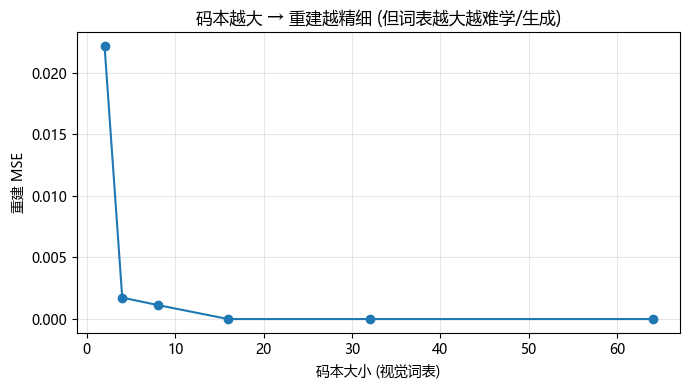

权衡: 码本太小重建糊 (信息丢); 太大词表巨大难学。真实 VQGAN 用几千~上万。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
ks = [2,4,8,16,32,64]
mses = [vq.reconstruct(img, codebook_size=k, patch=2, seed=1)[2] for k in ks]
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ks, mses, 'o-')
ax.set_xlabel('码本大小 (视觉词表)'); ax.set_ylabel('重建 MSE')
ax.set_title('码本越大 → 重建越精细 (但词表越大越难学/生成)'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('权衡: 码本太小重建糊 (信息丢); 太大词表巨大难学。真实 VQGAN 用几千~上万。')

## 4. 反思
你把图变成了离散 token 并重建, 看清了「码本大小 vs 重建质量」的权衡。带走:
- VQ 把连续图量化成离散 token (像视觉的词), 这是让 LLM 画图的前提。
- 离散化有损 (受码本限制), 但换来「复用全部文本生成机器」。
下一步 N2: 既然图是 token 串, 像生成文本一样自回归生成它 —— 让「LLM 画图」。